# Chapter B. Statistical Hypothesis Testing

## Learning Objectives

After completing this chapter, you should be able to:
1. Define a null hypothesis（原假设）and one-sided alternative for lift.
2. Derive the 2×2 table and fixed-margin hypergeometric distribution.
3. Explain conditional exchangeability（条件可交换性）and distinguish independence from a valid permutation law.
4. Compute exact and plus-one Monte Carlo p-values.
5. Explain outcome-independent screening and its limits.

**Connection to STARM:** The examples mirror the binary outcome, fixed antecedent indicators, lagged transactions, and overlapping spatial supports in the STARM manuscript. They are teaching examples, not reproductions of manuscript results.

> **Teaching philosophy:** start with the general statistical problem, build mathematical intuition, and use STARM as one illustrative case study. The new sections precede the original computational labs.

## Why Study This? — Motivation, Scope, and Real-World Problems

A statistically interesting pattern is not necessarily evidence against chance. Hypothesis testing provides a disciplined way to ask whether the data are surprising under a specific **data-generating explanation**, and makes the cost of false alarms explicit. It is used in randomized clinical trials, A/B testing, environmental monitoring, policy evaluations, and scientific discovery.

**Questions it answers:** What exactly is being tested? What distribution would we observe if the null model held? How surprising is the observed result? How much uncertainty remains?

**What it cannot answer alone:** Whether the null is true, whether the effect matters practically, or whether a statistically significant association is causal.

**Example beyond STARM:** A treatment/control trial compares the probability of improvement, and an online experiment compares conversion rates. In both, the validity of a p-value depends on the allocation or sampling model—not just the formula.

---

## Conceptual Roadmap

**Scientific problem → statistical representation → assumptions → mathematics → computational experiment → diagnostics → interpretation.**

The chapters are standalone: STARM is a later application, not the reason these mathematical ideas exist.

## Foundations and Mathematical Derivations

### From a scientific question to a test
1. Form a **statistical estimand (目标统计量)**, e.g. a difference in event probabilities, $\Delta=P(Y=1\mid X=1)-P(Y=1\mid X=0)$.
2. Specify $H_0$ and $H_1$ *before observing the test outcome*. For a positive association $H_0:\Delta=0$ vs $H_1:\Delta>0$.
3. State a sampling/randomization model. A null hypothesis about a marginal probability is **not** automatically an exchangeability assumption.
4. Choose a statistic $T(D)$ and calculate its reference distribution under $H_0$.
5. Define $p=P_{H_0}(T(D^*)\ge T(D_{obs}))$ for a one-sided test. A p-value is **not** $P(H_0\mid D)$.

### The fixed-margin hypergeometric derivation
Given $N$ units, $n$ antecedent-positive units, and $m$ positive outcomes, let $K$ count joint positives. Under a **uniform fixed-margin allocation** there are $\binom Nm$ equally likely outcome allocations. For exactly $k$ positive outcomes in the antecedent group, choose $k$ from its $n$ units and $m-k$ from the remaining $N-n$ units. Thus

$$P(K=k\mid N,n,m,H_0)=\frac{\binom nk\binom{N-n}{m-k}}{\binom Nm},\quad \max(0,m-N+n)\le k\le\min(n,m).$$

Then $E[K]=nm/N$, $\mathrm{Var}(K)=n(m/N)(1-m/N)(N-n)/(N-1)$, and $\mathrm{Lift}=KN/(nm)$ for $nm>0$. Hence $E[\mathrm{Lift}]=1$. This is an exact null result **under the stated allocation model**, not for every observational data set.

### Error, power and confidence intervals
Type I error (第一类错误) is rejecting a true null; Type II error (第二类错误) is missing an alternative. Power (检验功效) is $1-\beta$. A confidence interval is built from a coverage procedure; it is not a probability distribution over a fixed parameter. Small p-values can coexist with negligible effects in large samples.

### Randomization versus parametric inference
A z-test assumes a standardized statistic has an adequate reference distribution. A permutation test assumes specific allocations are exchangeable under $H_0$. A bootstrap resamples observations to approximate an estimator's sampling distribution; ordinary row bootstrap also fails if spatial/temporal dependence is ignored.

### Critical thinking checkpoint
Before running code, write down which observations are assumed independent or exchangeable and explain why. Revisit this statement after inspecting the visualizations.

## Additional Derivation Visualization — General-Purpose Example

The following self-contained experiment illustrates a general statistical principle, not STARM-specific results. Check how the plot corresponds to the formulas above.

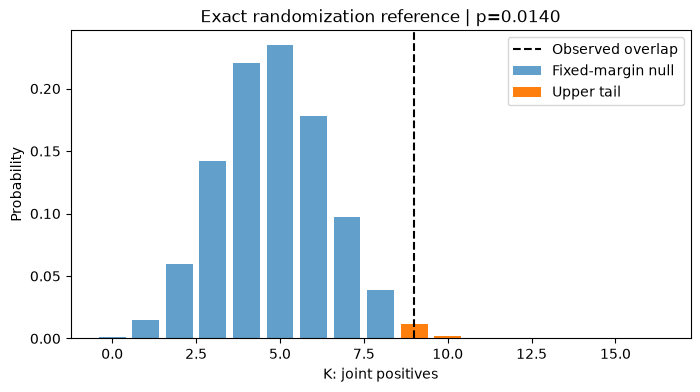

Expected K: 4.8 Observed lift: 1.875


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, norm
N, n, m = 80, 24, 16
k = np.arange(max(0,m-(N-n)), min(n,m)+1)
pmf = hypergeom.pmf(k,N,m,n)
observed_k = 9
pvalue = hypergeom.sf(observed_k-1,N,m,n)
fig,ax=plt.subplots(figsize=(8,4))
ax.bar(k,pmf,alpha=.7,label='Fixed-margin null')
ax.bar(k[k>=observed_k],pmf[k>=observed_k],label='Upper tail')
ax.axvline(observed_k,color='black',ls='--',label='Observed overlap')
ax.set(xlabel='K: joint positives',ylabel='Probability',title=f'Exact randomization reference | p={pvalue:.4f}')
ax.legend();plt.show()
print('Expected K:',n*m/N,'Observed lift:', observed_k*N/(n*m))

```mermaid
flowchart LR
    A[Define eligible transactions] --> B[Freeze X candidates]
    B --> C[Specify allocation null]
    C --> D[Compute observed lift]
    D --> E[Exact or Monte Carlo tail]
    E --> F[Assess assumptions]
```

This chapter follows the same structure as the supplied MCLP tutorial: conceptual workflow, formal definition, assumptions, a hand-worked example, executable Python experiments, sensitivity checks, common pitfalls, and a quiz.

---

## Formal Definition and Core Equations

### Notation

| Symbol | Meaning |
|---|---|
| $N$ | number of eligible anchor-period transactions |
| $m=\sum_i Y_i$ | target-positive count（阳性交易数量） |
| $n=\sum_i X_i$ | antecedent-positive count |
| $K=\sum_i X_iY_i$ | co-occurrence count |
| $X_i,Y_i\in\{0,1\}$ | antecedent, target indicators |
| $L$ | lift（提升度） |

$$\widehat L=\frac{K/n}{m/N}=\frac{KN}{nm},\qquad K\mid X,N,m\sim\mathrm{Hypergeom}(N,m,n)$$

$$p_{\rm exact}=P(K^*\ge K_{\rm obs}\mid N,m,n),\qquad \hat p_{MC}=\frac{1+\sum_{b=1}^{B}\mathbf{1}(L_b^*\ge L_{obs})}{B+1}.$$

---

## Core Mechanisms and Concepts

### What is a valid null?

The candidate-level statement $P(Y=1\mid X=1)=P(Y=1)$ is weaker than **uniform allocation of the whole target vector** conditional on the number of positives. Permuting the $Y$ rows tests that stronger allocation law, not every possible notion of independence.

### Fixed-margin conditioning

Holding $N,m,n$ fixed leaves only $K$ random. This yields a hypergeometric tail and makes confidence and lift monotone functions of $K$. The same candidate frequency leads to the same reference distribution under this particular null.

### Discrete exact tests

The attainable values of $K$ are integers, so exact p-values can be conservative. Monte Carlo ranks use **plus one** to avoid zero p-values, but more permutations cannot repair an incorrect null.

### Screening

Support screening computed using $X$ alone freezes candidates before looking at $Y$. It avoids outcome-driven selection, but does **not** by itself ensure conditional exchangeability or BH validity.

## Assumptions, Strengths, Limitations, and Trade-offs

Assume binary measurements are accurate, the candidate set is fixed independently of target outcomes, and each allocation of the $m$ positives to $N$ rows is equally likely under the null. Strength: finite-sample exact conditional reference. Limit: spatially shared events, seasonality, uneven risk, and serial dependence often violate this allocation model.

**Trade-off:** conditioning on the observed total removes uncertainty about baseline prevalence but does not preserve the geography of event occurrence.

## Worked Toy Example

For $N=12$ sampled neighborhood-months, $m=4$ wildfire-positive contexts, and $n=5$ neighborhoods satisfying a lagged dry predicate, suppose $K=3$ co-occurrences.

$$\widehat L=\frac{3/5}{4/12}=1.8.$$

Under complete label exchangeability, calculate $P(K^*\ge3)$ from $\mathrm{Hypergeom}(12,4,5)$. A lift above one is not equivalent to statistical significance.

## Python Lab: Set Up the Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, binom

SEED = 41020001
rng = np.random.default_rng(SEED)
print("Reproducible random seed:", SEED)

Reproducible random seed: 41020001


## Build the 2×2 table

Use a transparent binary example to check every denominator.

In [3]:
N,m,n,K=12,4,5,3
obs=pd.DataFrame([[K,n-K],[m-K,N-m-n+K]],index=['X=1','X=0'],columns=['Y=1','Y=0'])
print(obs)
print('support=',K/N,'confidence=',K/n,'lift=',K*N/(n*m))

     Y=1  Y=0
X=1    3    2
X=0    1    6
support= 0.25 confidence= 0.6 lift= 1.8


**Interpretation.** Rule support is joint prevalence; antecedent support is n/N. The rows of the table must sum to n and N−n.

## Evaluate an exact tail

The hypergeometric null fixes the two margins.

Exact one-sided p-value: 0.151515


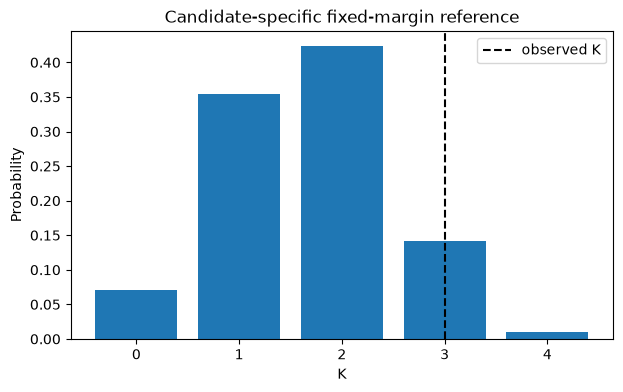

In [4]:
ks=np.arange(max(0,n+m-N),min(n,m)+1)
probs=hypergeom.pmf(ks,N,m,n)
p_exact=hypergeom.sf(K-1,N,m,n)
print('Exact one-sided p-value:',round(p_exact,6))
fig,ax=plt.subplots(figsize=(7,4));ax.bar(ks,probs);ax.axvline(K,color='black',linestyle='--',label='observed K');ax.set(xlabel='K',ylabel='Probability',title='Candidate-specific fixed-margin reference');ax.legend();plt.show()

**Interpretation.** The exact tail sums all attainable overlaps at least as large as the observed overlap.

## Run the Monte Carlo test

Compare permutation approximation to the exact reference without using forbidden zero p-values.

In [5]:
B=9999
X=np.r_[np.ones(n,dtype=int),np.zeros(N-n,dtype=int)]
Y=np.r_[np.ones(m,dtype=int),np.zeros(N-m,dtype=int)]
K_perm=np.array([np.dot(X,rng.permutation(Y)) for _ in range(B)])
p_mc=(1+np.count_nonzero(K_perm>=K))/(B+1)
print({'exact':p_exact,'Monte Carlo plus-one':p_mc,'minimum_possible_MC_p':1/(B+1)})

{'exact': np.float64(0.15151515151515152), 'Monte Carlo plus-one': np.float64(0.1496), 'minimum_possible_MC_p': 0.0001}


**Interpretation.** Agreement of exact and Monte Carlo tails checks computation under the SAME null; it does not check whether the null is geographically justified.

## Explore the sensitivity to support

For a fixed total prevalence, changing candidate prevalence changes the attainable null spread.

In [6]:
rows=[]
for nn in [3,5,7,9]:
 kk=min(nn,m)
 rows.append({'antecedent_count':nn,'E[K]':nn*m/N,'Var[K]':hypergeom.var(N,m,nn),'P(K>=max)':hypergeom.sf(kk-1,N,m,nn)})
print(pd.DataFrame(rows).round(4))

   antecedent_count    E[K]  Var[K]  P(K>=max)
0                 3  1.0000  0.5455     0.0182
1                 5  1.6667  0.7071     0.0101
2                 7  2.3333  0.7071     0.0707
3                 9  3.0000  0.5455     0.2545


**Interpretation.** Candidate-specific uncertainty changes with n even when background event prevalence remains constant.

---

## Common Pitfalls and Misunderstandings

1. **Lift > 1 is not a p-value.**
2. **Marginal independence does not imply row-exchangeability.**
3. **Permuting labels is not the same as simulating a spatial point process.**
4. **Using more permutations does not solve model misspecification.**
5. **Outcome-free candidate screening does not prove multiplicity control.**

---

## Quiz — Self-Assessment (Answers Hidden)

Try each question before expanding **Answer**. The folded format follows the supplied `mclp.ipynb` template.

### Q1: Why is learning a sampling or randomization model necessary before using a p-value?

A. It guarantees a small p-value  
B. It defines how unusual results are calculated under the null  
C. It determines a causal effect  
D. It eliminates bias

<details>
<summary>Answer</summary>

**B. The model defines the reference distribution; a formula alone is not a validity guarantee.**

</details>

---

### Q2: Under the fixed-margin model, what is held constant?

A. The sample mean only  
B. N, antecedent count n, and positive-outcome count m  
C. Every individual outcome  
D. The observed overlap K

<details>
<summary>Answer</summary>

**B. Only the margins and eligible units are fixed; K varies across allocations.**

</details>

---

### Q3: Does a p-value of 0.03 mean that the null is 3% likely?

A. Yes  
B. Only with 1,000 samples  
C. No  
D. Only for one-sided tests

<details>
<summary>Answer</summary>

**C. It is a probability of a statistic at least as extreme under the specified null reference, not a posterior probability.**

</details>

---

### Q4: Why might a conventional row bootstrap fail for spatial data?

A. It uses too many draws  
B. It treats dependent rows as independent  
C. It requires binary data  
D. It is always conservative

<details>
<summary>Answer</summary>

**B. Resampling single units destroys dependence; block or model-based resampling may be required.**

</details>

---

### Reflection Question (no prescribed solution)

Name one assumption violation in your own research area and propose a simulation to measure how much it matters.


---

## Suggested Reading and STARM Crosswalk

- Agrawal & Srikant (1994): frequent-itemset search (background).
- Hope (1968); Phipson & Smyth (2010): randomization/Monte Carlo p-values (Chapter B).
- Benjamini & Hochberg (1995); Benjamini & Yekutieli (2001): multiple testing and dependence (Chapter C).
- Baddeley, Rubak & Turner (2015): spatial point patterns (Chapter D).
- Winkler et al. (2014): exchangeability blocks and permutation designs (Chapters B, D, E).
- STARM manuscript: Sections 3.3–3.6 for reference assumptions; Section 4 for simulations; Sections 5–6 for empirical limitations.

**Practice task:** Write a short reviewer note distinguishing a descriptive association from an inferential discovery, explicitly naming the null model and its assumptions.